In [33]:
df = pd.read_csv("top_rated_movies.csv")

print(df.shape)
df.head()

(10000, 10)


,adult,id,original_language,original_title,overview,popularity,release_date,title,vote_average,vote_count
0,False,278,en,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,46.3708,1994-09-23,The Shawshank Redemption,8.718,30171
1,False,238,en,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",42.0006,1972-03-14,The Godfather,8.686,22787
2,False,240,en,The Godfather Part II,In the continuing saga of the Corleone crime f...,26.8671,1974-12-20,The Godfather Part II,8.571,13812
3,False,424,en,Schindler's List,The true story of how businessman Oskar Schind...,24.2944,1993-12-15,Schindler's List,8.567,17341
4,False,389,en,12 Angry Men,The defense and the prosecution have rested an...,19.4971,1957-04-10,12 Angry Men,8.559,9908


In [34]:
corpus = df.dropna(subset=['overview'])['overview'].reset_index(drop=True)
print(f"Broj primeraka: {len(corpus)}")

Broj primeraka: 9998


In [35]:
import re
import string
from bs4 import BeautifulSoup

def clean_text(text):
    text = text.lower()
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\W+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_corpus = [clean_text(doc) for doc in corpus]
print("Cleaned Corpus:\n", cleaned_corpus[:5])

Cleaned Corpus:
 ['imprisoned in the s for the double murder of his wife and her lover upstanding banker andy dufresne begins a new life at the shawshank prison where he puts his accounting skills to work for an amoral warden during his long stretch in prison dufresne comes to be admired by the other inmates including an older prisoner named red for his integrity and unquenchable sense of hope', 'spanning the years to a chronicle of the fictional italianamerican corleone crime family when organized crime family patriarch vito corleone barely survives an attempt on his life his youngest son michael steps in to take care of the wouldbe killers launching a campaign of bloody revenge', 'in the continuing saga of the corleone crime family a young vito corleone grows up in sicily and in s new york in the s michael corleone attempts to expand the family business into las vegas hollywood and cuba', 'the true story of how businessman oskar schindler saved over a thousand jewish lives from the n

In [36]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

tokenized_corpus = [word_tokenize(doc) for doc in cleaned_corpus]
print("Tokenized Corpus:\n", tokenized_corpus[:5])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nikola.bakic\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nikola.bakic\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Tokenized Corpus:
 [['imprisoned', 'in', 'the', 's', 'for', 'the', 'double', 'murder', 'of', 'his', 'wife', 'and', 'her', 'lover', 'upstanding', 'banker', 'andy', 'dufresne', 'begins', 'a', 'new', 'life', 'at', 'the', 'shawshank', 'prison', 'where', 'he', 'puts', 'his', 'accounting', 'skills', 'to', 'work', 'for', 'an', 'amoral', 'warden', 'during', 'his', 'long', 'stretch', 'in', 'prison', 'dufresne', 'comes', 'to', 'be', 'admired', 'by', 'the', 'other', 'inmates', 'including', 'an', 'older', 'prisoner', 'named', 'red', 'for', 'his', 'integrity', 'and', 'unquenchable', 'sense', 'of', 'hope'], ['spanning', 'the', 'years', 'to', 'a', 'chronicle', 'of', 'the', 'fictional', 'italianamerican', 'corleone', 'crime', 'family', 'when', 'organized', 'crime', 'family', 'patriarch', 'vito', 'corleone', 'barely', 'survives', 'an', 'attempt', 'on', 'his', 'life', 'his', 'youngest', 'son', 'michael', 'steps', 'in', 'to', 'take', 'care', 'of', 'the', 'wouldbe', 'killers', 'launching', 'a', 'campaign'

In [37]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
filtered_corpus = [[word for word in doc if word not in stop_words] for doc in tokenized_corpus]
print("Stopword Removed Corpus:\n", filtered_corpus[:5])

Stopword Removed Corpus:
 [['imprisoned', 'double', 'murder', 'wife', 'lover', 'upstanding', 'banker', 'andy', 'dufresne', 'begins', 'new', 'life', 'shawshank', 'prison', 'puts', 'accounting', 'skills', 'work', 'amoral', 'warden', 'long', 'stretch', 'prison', 'dufresne', 'comes', 'admired', 'inmates', 'including', 'older', 'prisoner', 'named', 'red', 'integrity', 'unquenchable', 'sense', 'hope'], ['spanning', 'years', 'chronicle', 'fictional', 'italianamerican', 'corleone', 'crime', 'family', 'organized', 'crime', 'family', 'patriarch', 'vito', 'corleone', 'barely', 'survives', 'attempt', 'life', 'youngest', 'son', 'michael', 'steps', 'take', 'care', 'wouldbe', 'killers', 'launching', 'campaign', 'bloody', 'revenge'], ['continuing', 'saga', 'corleone', 'crime', 'family', 'young', 'vito', 'corleone', 'grows', 'sicily', 'new', 'york', 'michael', 'corleone', 'attempts', 'expand', 'family', 'business', 'las', 'vegas', 'hollywood', 'cuba'], ['true', 'story', 'businessman', 'oskar', 'schindl

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikola.bakic\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [38]:
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

pos_tagged_corpus = [nltk.pos_tag(doc) for doc in filtered_corpus]
print("POS Tagged Corpus:\n", pos_tagged_corpus[:5])

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\nikola.bakic\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\nikola.bakic\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


POS Tagged Corpus:
 [[('imprisoned', 'VBN'), ('double', 'JJ'), ('murder', 'NN'), ('wife', 'NN'), ('lover', 'IN'), ('upstanding', 'JJ'), ('banker', 'NN'), ('andy', 'NN'), ('dufresne', 'NN'), ('begins', 'VBZ'), ('new', 'JJ'), ('life', 'NN'), ('shawshank', 'NN'), ('prison', 'NN'), ('puts', 'VBZ'), ('accounting', 'VBG'), ('skills', 'NNS'), ('work', 'VBP'), ('amoral', 'JJ'), ('warden', 'NNS'), ('long', 'RB'), ('stretch', 'VBP'), ('prison', 'NN'), ('dufresne', 'NN'), ('comes', 'VBZ'), ('admired', 'JJ'), ('inmates', 'NNS'), ('including', 'VBG'), ('older', 'JJR'), ('prisoner', 'NN'), ('named', 'VBN'), ('red', 'JJ'), ('integrity', 'NN'), ('unquenchable', 'JJ'), ('sense', 'NN'), ('hope', 'NN')], [('spanning', 'VBG'), ('years', 'NNS'), ('chronicle', 'VBP'), ('fictional', 'JJ'), ('italianamerican', 'JJ'), ('corleone', 'NN'), ('crime', 'NN'), ('family', 'NN'), ('organized', 'VBN'), ('crime', 'NN'), ('family', 'NN'), ('patriarch', 'NN'), ('vito', 'NN'), ('corleone', 'NN'), ('barely', 'RB'), ('surviv

In [39]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

nltk.download('wordnet')

def get_wordnet_pos(tag: str) -> str:
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

lemmatizer = WordNetLemmatizer()
lemmatized_corpus = [
    [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in doc]
    for doc in pos_tagged_corpus
]
print("Lemmatized Corpus:\n", lemmatized_corpus[:5])

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nikola.bakic\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Lemmatized Corpus:
 [['imprison', 'double', 'murder', 'wife', 'lover', 'upstanding', 'banker', 'andy', 'dufresne', 'begin', 'new', 'life', 'shawshank', 'prison', 'put', 'account', 'skill', 'work', 'amoral', 'warden', 'long', 'stretch', 'prison', 'dufresne', 'come', 'admired', 'inmate', 'include', 'old', 'prisoner', 'name', 'red', 'integrity', 'unquenchable', 'sense', 'hope'], ['span', 'year', 'chronicle', 'fictional', 'italianamerican', 'corleone', 'crime', 'family', 'organize', 'crime', 'family', 'patriarch', 'vito', 'corleone', 'barely', 'survive', 'attempt', 'life', 'young', 'son', 'michael', 'step', 'take', 'care', 'wouldbe', 'killer', 'launch', 'campaign', 'bloody', 'revenge'], ['continue', 'saga', 'corleone', 'crime', 'family', 'young', 'vito', 'corleone', 'grow', 'sicily', 'new', 'york', 'michael', 'corleone', 'attempt', 'expand', 'family', 'business', 'la', 'vega', 'hollywood', 'cuba'], ['true', 'story', 'businessman', 'oskar', 'schindler', 'save', 'thousand', 'jewish', 'life',

In [40]:
for i in range(5):
    print("ORIGINAL:", corpus[i])
    print("PROCESSED:", lemmatized_corpus[i])
    print("-" * 100)

orig_lengths = [len(doc.split()) for doc in corpus]
proc_lengths = [len(doc) for doc in lemmatized_corpus]
print(f"\nProsecna duzina originala: {sum(orig_lengths)/len(orig_lengths):.2f} reci")
print(f"Prosecna duzina posle obrade: {sum(proc_lengths)/len(proc_lengths):.2f} reci")

orig_vocab = set(w for doc in corpus for w in doc.lower().split())
proc_vocab = set(w for doc in lemmatized_corpus for w in doc)
print(f"\nVelicina vokabulara original: {len(orig_vocab)}")
print(f"Velicina vokabulara posle obrade: {len(proc_vocab)}")

ORIGINAL: Imprisoned in the 1940s for the double murder of his wife and her lover, upstanding banker Andy Dufresne begins a new life at the Shawshank prison, where he puts his accounting skills to work for an amoral warden. During his long stretch in prison, Dufresne comes to be admired by the other inmates -- including an older prisoner named Red -- for his integrity and unquenchable sense of hope.
PROCESSED: ['imprison', 'double', 'murder', 'wife', 'lover', 'upstanding', 'banker', 'andy', 'dufresne', 'begin', 'new', 'life', 'shawshank', 'prison', 'put', 'account', 'skill', 'work', 'amoral', 'warden', 'long', 'stretch', 'prison', 'dufresne', 'come', 'admired', 'inmate', 'include', 'old', 'prisoner', 'name', 'red', 'integrity', 'unquenchable', 'sense', 'hope']
----------------------------------------------------------------------------------------------------
ORIGINAL: Spanning the years 1945 to 1955, a chronicle of the fictional Italian-American Corleone crime family. When organized c

In [41]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# vokabular svih jedinstvenih reci u korpusu
vocab = sorted(set(word for doc in lemmatized_corpus for word in doc))
print(f"Velicina vokabulara: {len(vocab)}")

encoder = OneHotEncoder(sparse_output=False)
word_vectors = encoder.fit_transform(np.array(vocab).reshape(-1, 1))

word_to_vec = dict(zip(vocab, word_vectors))

# primer: one-hot vektor za prvu rec prvog dokumenta
example_word = lemmatized_corpus[0][0]
print(f"Rec: {example_word}")
print(f"One-hot vektor (prvih 20 dimenzija): {word_to_vec[example_word][:20]}")
print(f"Dimenzionalnost vektora: {word_to_vec[example_word].shape}")

Velicina vokabulara: 25261
Rec: imprison
One-hot vektor (prvih 20 dimenzija): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Dimenzionalnost vektora: (25261,)


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    tokenizer=lambda doc: doc,
    preprocessor=lambda doc: doc,
    lowercase=False,
    token_pattern=None
)

tfidf_matrix = tfidf.fit_transform(lemmatized_corpus)

print(f"Oblik TF-IDF matrice: {tfidf_matrix.shape}")
print(f"Velicina vokabulara: {len(tfidf.vocabulary_)}")

print("\nIDF vrednosti (prvih 10 reci):")
for word, idf_val in list(zip(tfidf.get_feature_names_out(), tfidf.idf_))[:10]:
    print(f"  {word}: {idf_val:.4f}")

print("\nWord indexes (prvih 10):")
print(dict(list(tfidf.vocabulary_.items())[:10]))

print("\nTF-IDF vektor za prvi dokument (nenula vrednosti):")
first_doc_vec = tfidf_matrix[0].toarray()[0]
nonzero_idx = first_doc_vec.nonzero()[0]
feature_names = tfidf.get_feature_names_out()
for idx in nonzero_idx:
    print(f"  {feature_names[idx]}: {first_doc_vec[idx]:.4f}")



Oblik TF-IDF matrice: (9998, 25261)
Velicina vokabulara: 25261

IDF vrednosti (prvih 10 reci):
  aa: 9.5171
  aames: 9.5171
  aaron: 7.7253
  aba: 9.5171
  aback: 9.5171
  abagnale: 9.5171
  abahachi: 9.5171
  abandon: 5.6994
  abandoned: 9.1116
  abandonment: 9.5171

Word indexes (prvih 10):
{'imprison': 10987, 'double': 6379, 'murder': 15056, 'wife': 24640, 'lover': 13330, 'upstanding': 23774, 'banker': 1696, 'andy': 791, 'dufresne': 6591, 'begin': 1963}

TF-IDF vektor za prvi dokument (nenula vrednosti):
  account: 0.1637
  admired: 0.2253
  amoral: 0.2089
  andy: 0.1776
  banker: 0.1776
  begin: 0.0897
  come: 0.0929
  double: 0.1612
  dufresne: 0.4506
  hope: 0.1217
  imprison: 0.1637
  include: 0.1242
  inmate: 0.1696
  integrity: 0.1993
  life: 0.0664
  long: 0.1193
  lover: 0.1320
  murder: 0.0954
  name: 0.1002
  new: 0.0733
  old: 0.0977
  prison: 0.2345
  prisoner: 0.1456
  put: 0.1095
  red: 0.1473
  sense: 0.1422
  shawshank: 0.2253
  skill: 0.1389
  stretch: 0.1792
  unqu

In [43]:
from gensim.models import Word2Vec
import gensim
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt')
import warnings

warnings.filterwarnings(action='ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nikola.bakic\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [44]:
model2 = gensim.models.Word2Vec(lemmatized_corpus, min_count=5, vector_size=100,
                                window=5, sg=1, seed=42, epochs=20)

In [45]:
print(f"Velicina vokabulara Word2Vec modela: {len(model2.wv)}")
print(f"Vektor za rec 'murder' (prvih 10 vrednosti): {model2.wv['murder'][:10]}")
print(f"\nRec najslicnije reci 'murder':")
for word, score in model2.wv.most_similar('murder', topn=5):
    print(f"  {word}: {score:.4f}")

Velicina vokabulara Word2Vec modela: 6547
Vektor za rec 'murder' (prvih 10 vrednosti): [-0.11137911  0.4129637  -0.29486844 -0.44078064 -0.6858111   0.17336383
 -0.14083673  0.566826   -0.0796092  -0.5384175 ]

Rec najslicnije reci 'murder':
  rape: 0.5911
  strangle: 0.5496
  interrogation: 0.5384
  blame: 0.5337
  killing: 0.5307


In [46]:
example_word = "murder"

print(f"One-hot dimenzionalnost: {word_to_vec[example_word].shape}, nenula elemenata: {int(word_to_vec[example_word].sum())}")
print(f"TF-IDF dimenzionalnost: {tfidf_matrix.shape[1]}")
print(f"Word2Vec dimenzionalnost: {model2.wv[example_word].shape}")

print(f"\nOne-hot ne hvata semantiku (svaka rec je ortogonalna na svaku drugu).")
print(f"TF-IDF takodje ne hvata semantiku, samo tezinu reci po dokumentu.")
print(f"Word2Vec hvata semantiku, najslicnije reci reci '{example_word}':")
for word, score in model2.wv.most_similar(example_word, topn=5):
    print(f"  {word}: {score:.4f}")

One-hot dimenzionalnost: (25261,), nenula elemenata: 1
TF-IDF dimenzionalnost: 25261
Word2Vec dimenzionalnost: (100,)

One-hot ne hvata semantiku (svaka rec je ortogonalna na svaku drugu).
TF-IDF takodje ne hvata semantiku, samo tezinu reci po dokumentu.
Word2Vec hvata semantiku, najslicnije reci reci 'murder':
  rape: 0.5911
  strangle: 0.5496
  interrogation: 0.5384
  blame: 0.5337
  killing: 0.5307


In [47]:
from sklearn.metrics import silhouette_score
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

word_freq = Counter(word for doc in lemmatized_corpus for word in doc)
top_words = [w for w, _ in word_freq.most_common(200) if len(w) > 2]

def cluster_and_plot(vectors: np.ndarray, words: list, title: str, n_clusters: int = 8, dim: int = 2):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(vectors)

    reduced = PCA(n_components=dim, random_state=42).fit_transform(vectors)

    fig = plt.figure(figsize=(14, 10))
    if dim == 3:
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(reduced[:, 0], reduced[:, 1], reduced[:, 2], c=labels, cmap='tab10', alpha=0.7)
        for i, w in enumerate(words):
            ax.text(reduced[i, 0], reduced[i, 1], reduced[i, 2], w, fontsize=7)
    else:
        ax = fig.add_subplot(111)
        ax.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='tab10', alpha=0.7)
        for i, w in enumerate(words):
            ax.annotate(w, (reduced[i, 0], reduced[i, 1]), fontsize=7)
    ax.set_title(title)
    plt.show()

    print(f"\n{title} - reci po klasterima:")
    for c in range(n_clusters):
        cluster_words = [w for w, l in zip(words, labels) if l == c]
        print(f"  Klaster {c}: {cluster_words[:15]}")
    return labels, reduced

def find_best_k(vectors: np.ndarray, title: str, k_range=range(8, 15)) -> int:
    inertias = []
    sil_scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(vectors)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(vectors, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(list(k_range), inertias, marker='o')
    axes[0].set_title(f"{title} - Elbow (inertia)")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("inertia")

    axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
    axes[1].set_title(f"{title} - Silhouette score")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("silhouette")
    plt.tight_layout()
    plt.show()

    best_k = list(k_range)[int(np.argmax(sil_scores))]
    print(f"{title}: najbolji k po silhouette skoru = {best_k}")
    return best_k

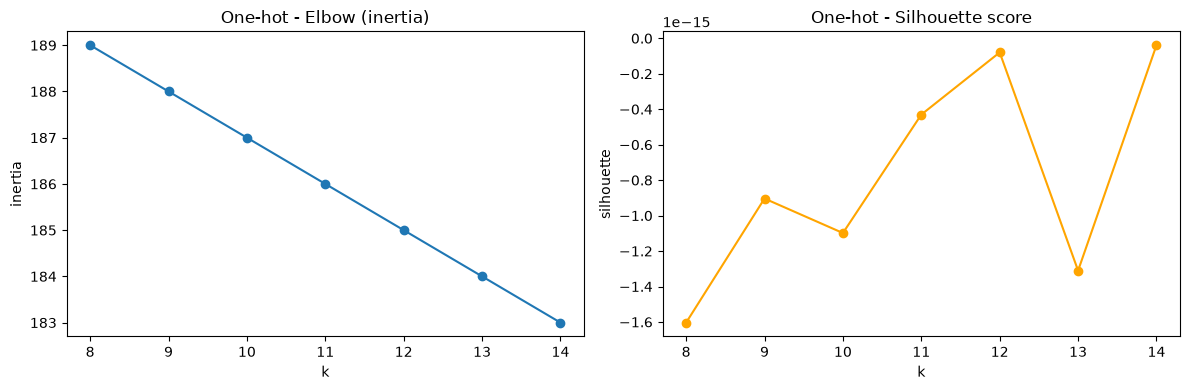

One-hot: najbolji k po silhouette skoru = 14


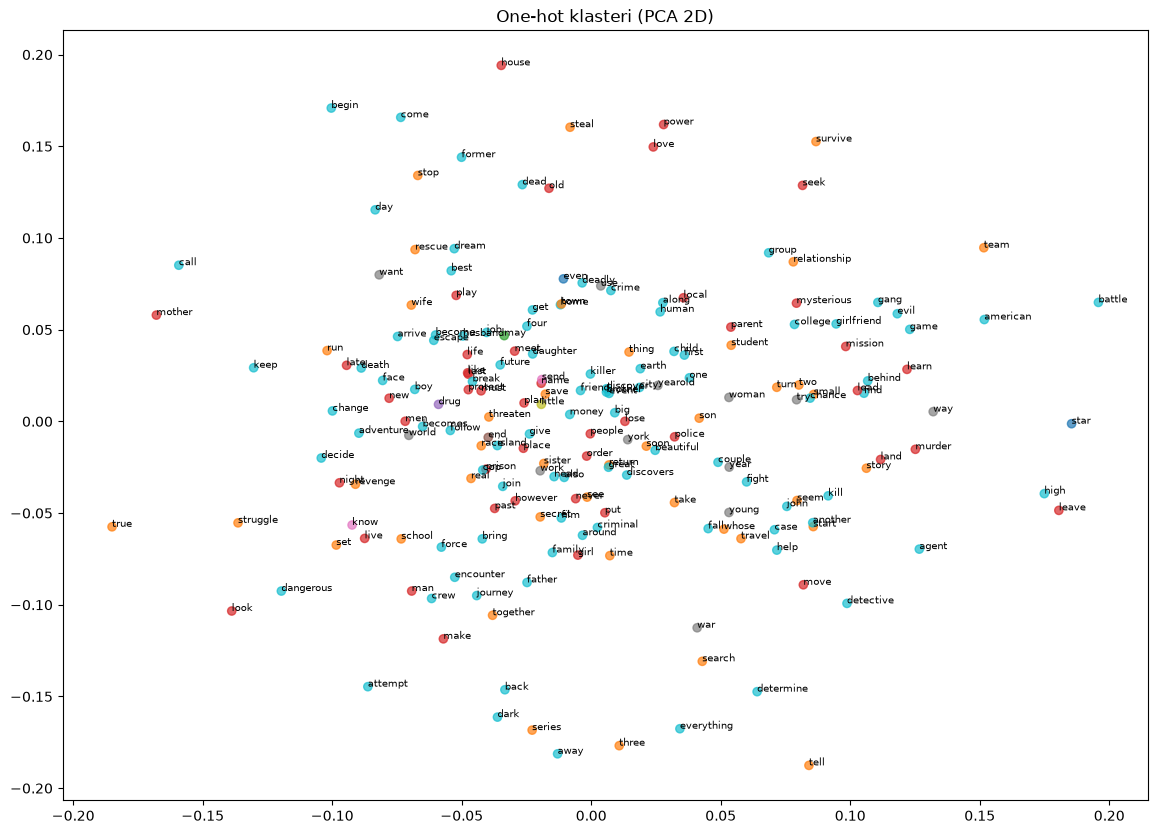


One-hot klasteri (PCA 2D) - reci po klasterima:
  Klaster 0: ['star']
  Klaster 1: ['even']
  Klaster 2: ['take', 'two', 'story', 'turn', 'time', 'school', 'set', 'soon', 'son', 'team', 'save', 'town', 'wife', 'return', 'secret']
  Klaster 3: ['may']
  Klaster 4: ['life', 'new', 'must', 'man', 'love', 'make', 'live', 'girl', 'meet', 'leave', 'murder', 'lead', 'mysterious', 'mother', 'old']
  Klaster 5: ['seek']
  Klaster 6: ['drug']
  Klaster 7: ['end']
  Klaster 8: ['know']
  Klaster 9: ['send']
  Klaster 10: ['young', 'world', 'year', 'woman', 'try', 'way', 'work', 'war', 'york', 'want', 'use', 'yearold']
  Klaster 11: ['little']
  Klaster 12: ['find', 'one', 'family', 'get', 'friend', 'become', 'force', 'help', 'begin', 'home', 'father', 'day', 'back', 'come', 'fall']
  Klaster 13: ['death']


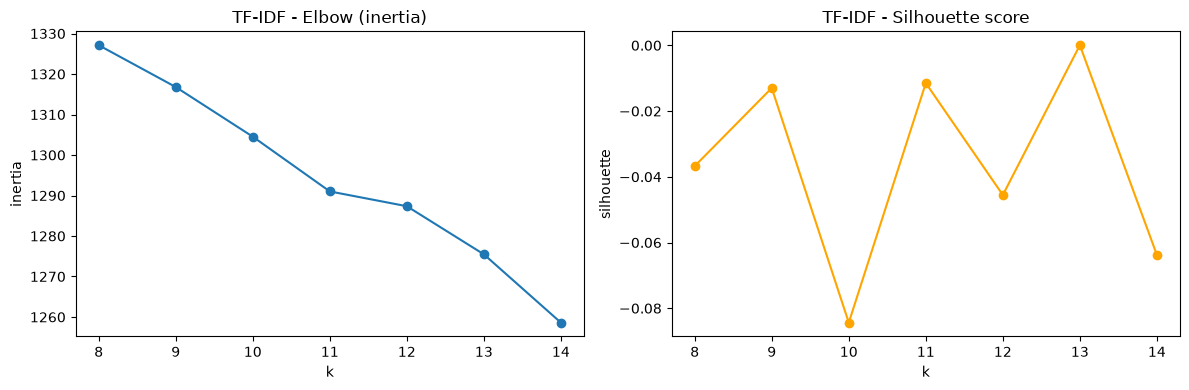

TF-IDF: najbolji k po silhouette skoru = 13


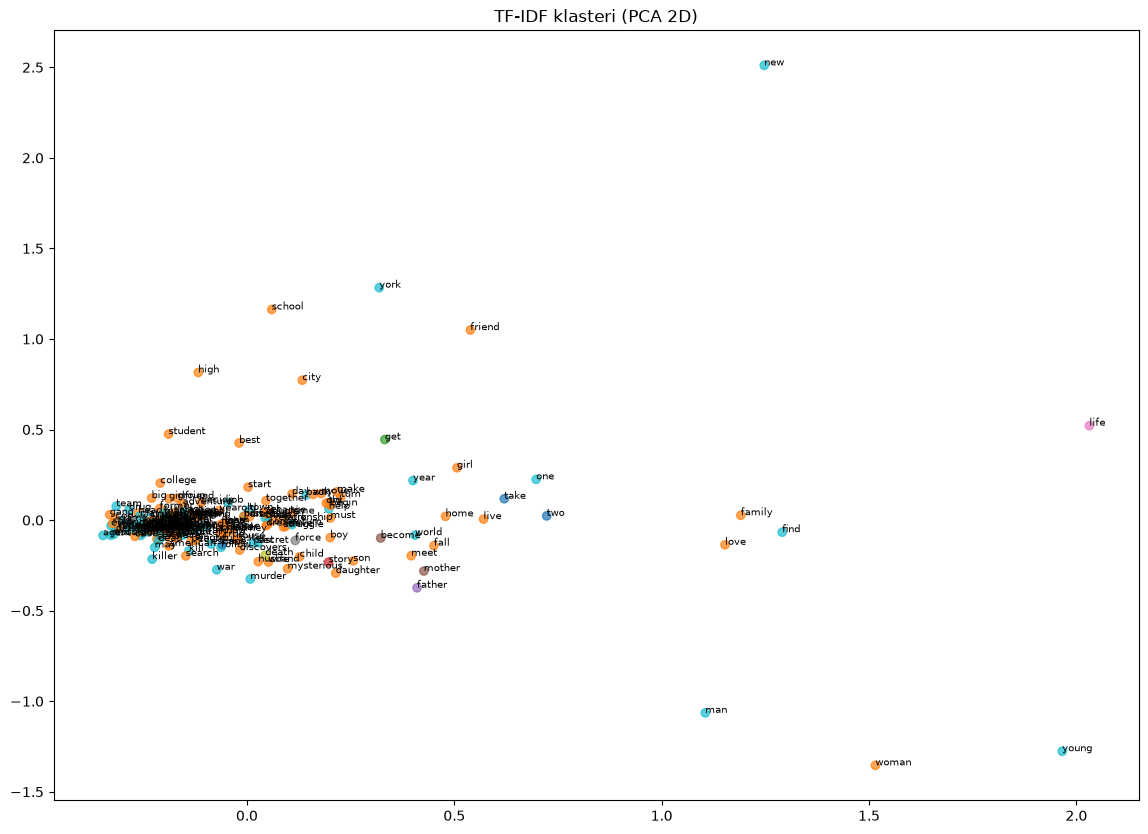


TF-IDF klasteri (PCA 2D) - reci po klasterima:
  Klaster 0: ['take']
  Klaster 1: ['two', 'men']
  Klaster 2: ['family', 'must', 'friend', 'love', 'woman', 'make', 'live', 'begin', 'try', 'turn', 'time', 'home', 'girl', 'school', 'meet']
  Klaster 3: ['get']
  Klaster 4: ['story']
  Klaster 5: ['father']
  Klaster 6: ['mother']
  Klaster 7: ['become']
  Klaster 8: ['life']
  Klaster 9: ['force']
  Klaster 10: ['death']
  Klaster 11: ['find', 'young', 'new', 'world', 'man', 'year', 'help', 'back', 'war', 'soon', 'murder', 'lead', 'team', 'save', 'town']
  Klaster 12: ['one']


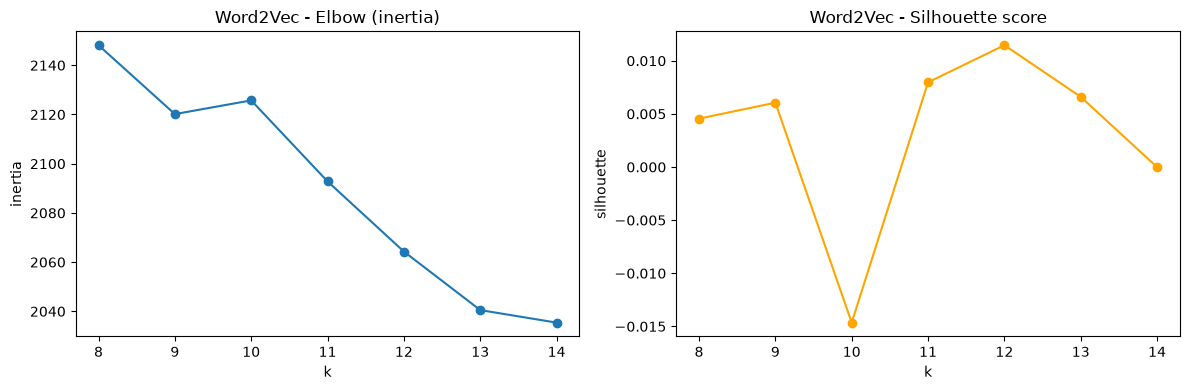

Word2Vec: najbolji k po silhouette skoru = 12


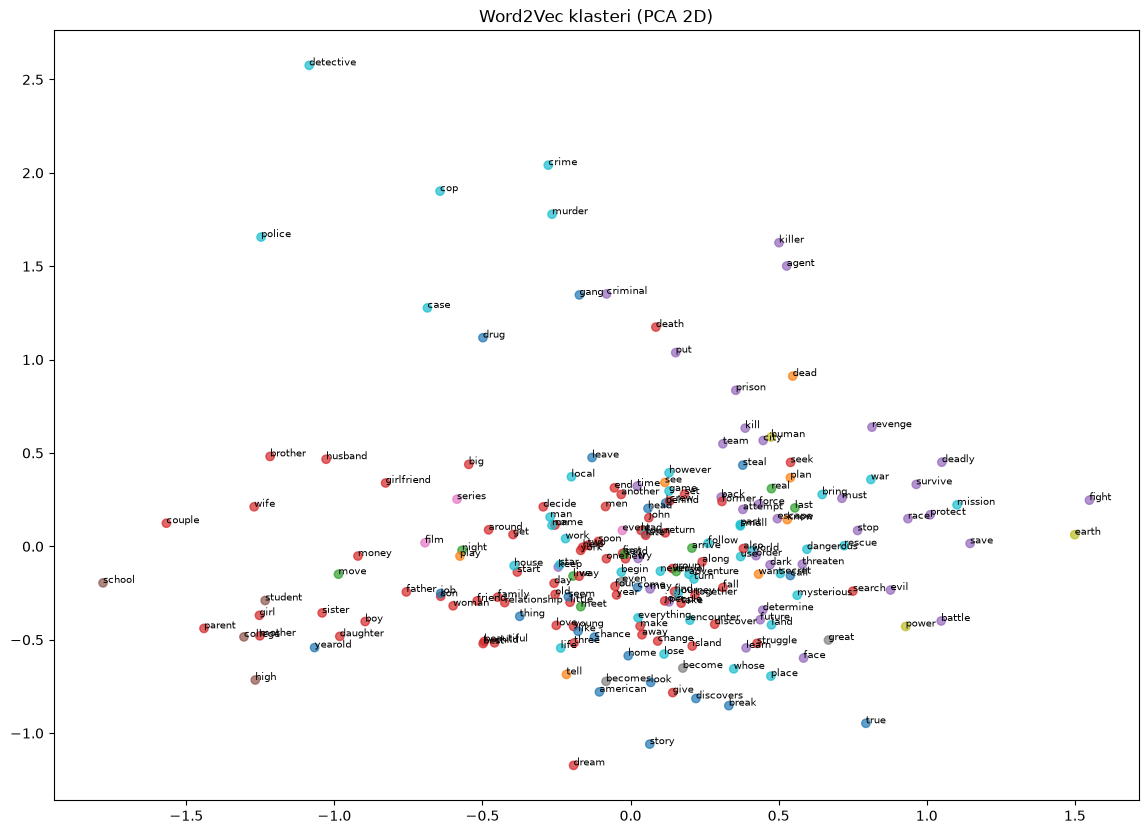


Word2Vec klasteri (PCA 2D) - reci po klasterima:
  Klaster 0: ['story', 'home', 'leave', 'true', 'thing', 'yearold', 'behind', 'look', 'seem', 'chance', 'like']
  Klaster 1: ['come', 'job', 'american', 'discovers', 'call', 'drug', 'gang', 'break', 'head', 'steal']
  Klaster 2: ['know', 'plan', 'want', 'see', 'tell', 'dead', 'play']
  Klaster 3: ['live', 'meet', 'move', 'night', 'travel', 'send', 'last', 'arrive', 'real']
  Klaster 4: ['find', 'young', 'new', 'one', 'take', 'family', 'two', 'get', 'friend', 'love', 'year', 'woman', 'make', 'help', 'father']
  Klaster 5: ['must', 'force', 'try', 'time', 'back', 'team', 'save', 'city', 'fight', 'face', 'kill', 'escape', 'killer', 'battle', 'learn']
  Klaster 6: ['school', 'high', 'student', 'college']
  Klaster 7: ['event', 'film', 'series']
  Klaster 8: ['become', 'even', 'great', 'becomes']
  Klaster 9: ['power', 'human', 'earth']
  Klaster 10: ['murder', 'police', 'crime', 'detective', 'cop', 'case']
  Klaster 11: ['life', 'world', 'm

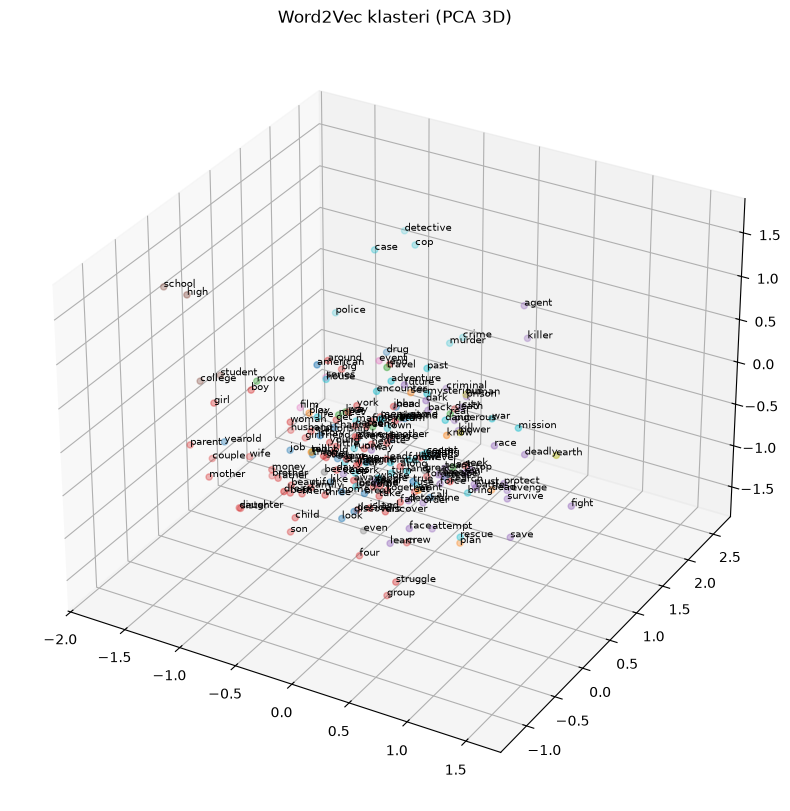


Word2Vec klasteri (PCA 3D) - reci po klasterima:
  Klaster 0: ['story', 'home', 'leave', 'true', 'thing', 'yearold', 'behind', 'look', 'seem', 'chance', 'like']
  Klaster 1: ['come', 'job', 'american', 'discovers', 'call', 'drug', 'gang', 'break', 'head', 'steal']
  Klaster 2: ['know', 'plan', 'want', 'see', 'tell', 'dead', 'play']
  Klaster 3: ['live', 'meet', 'move', 'night', 'travel', 'send', 'last', 'arrive', 'real']
  Klaster 4: ['find', 'young', 'new', 'one', 'take', 'family', 'two', 'get', 'friend', 'love', 'year', 'woman', 'make', 'help', 'father']
  Klaster 5: ['must', 'force', 'try', 'time', 'back', 'team', 'save', 'city', 'fight', 'face', 'kill', 'escape', 'killer', 'battle', 'learn']
  Klaster 6: ['school', 'high', 'student', 'college']
  Klaster 7: ['event', 'film', 'series']
  Klaster 8: ['become', 'even', 'great', 'becomes']
  Klaster 9: ['power', 'human', 'earth']
  Klaster 10: ['murder', 'police', 'crime', 'detective', 'cop', 'case']
  Klaster 11: ['life', 'world', 'm

(array([11,  4,  4,  4,  4,  4, 11,  4,  4,  5,  4, 11,  4,  4,  4,  8,  4,
         4,  5,  3,  4, 11,  0,  5, 11,  5,  0,  4,  4,  6,  3,  4,  4,  5,
         4,  1, 11, 11,  4,  0, 10,  4,  4,  4,  4, 11,  4,  5,  5, 11,  4,
         5,  4,  4,  4, 11,  5,  4,  5,  4,  4,  4,  4,  4,  2,  2,  4,  5,
         4,  6,  4,  4,  4, 11,  5,  5,  4,  4,  3, 10,  1,  5, 11,  4,  4,
        11,  5,  5,  5, 11,  3,  1,  4, 11,  4,  1,  0,  2,  5, 11,  4, 11,
         4,  5, 11,  6, 11,  5, 10,  1, 11,  4, 11,  5,  2,  4,  9,  8,  4,
         4, 11,  7,  7, 11,  4,  9,  3,  4,  0,  5, 11,  0,  5,  4,  0,  4,
         5, 11,  1,  1,  9, 11,  5,  3,  3,  5, 11,  8,  4,  1,  5,  4,  4,
        10,  5,  4,  1,  4,  5,  0,  7,  0,  5,  4, 11, 11, 11,  5, 10,  0,
         4, 10,  5,  3, 11,  0, 11,  8,  4,  4,  4,  3,  2,  4,  4,  5, 11,
         2,  2,  4,  5,  5,  1,  4,  6,  4,  4], dtype=int32),
 array([[-0.23584315, -0.54430544,  0.56332254],
        [ 0.14830185, -0.24198484, -0.25197116],
   

In [48]:
# One-hot
onehot_vectors = np.array([word_to_vec[w] for w in top_words])
k_onehot = find_best_k(onehot_vectors, "One-hot")
cluster_and_plot(onehot_vectors, top_words, "One-hot klasteri (PCA 2D)", n_clusters=k_onehot)

# TF-IDF
tfidf_vocab = tfidf.vocabulary_
tfidf_dense = tfidf_matrix.T.toarray()
tfidf_words = [w for w in top_words if w in tfidf_vocab]
tfidf_vectors = np.array([tfidf_dense[tfidf_vocab[w]] for w in tfidf_words])
k_tfidf = find_best_k(tfidf_vectors, "TF-IDF")
cluster_and_plot(tfidf_vectors, tfidf_words, "TF-IDF klasteri (PCA 2D)", n_clusters=k_tfidf)

# Word2Vec
w2v_words = [w for w in top_words if w in model2.wv]
w2v_vectors = np.array([model2.wv[w] for w in w2v_words])
k_w2v = find_best_k(w2v_vectors, "Word2Vec")
cluster_and_plot(w2v_vectors, w2v_words, "Word2Vec klasteri (PCA 2D)", n_clusters=k_w2v)
cluster_and_plot(w2v_vectors, w2v_words, "Word2Vec klasteri (PCA 3D)", n_clusters=k_w2v, dim=3)